<a href="https://colab.research.google.com/github/VedantPatil-99/deep-learning-notebooks/blob/main/LeNet5_MNIST_Digit_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import callbacks, layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
tf.random.set_seed(42)
np.random.seed(42)

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MNIST dataset loaded. X_train shape: (60000, 28, 28), y_train shape: (60000,)
Preprocessing MNIST dataset for CNN...
Preprocessing complete. X_train shape: (60000, 28, 28, 1)
LeNet-5 Model built successfully
Starting training for 10 epochs
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8863 - loss: 0.4002 - val_accuracy: 0.9630 - val_loss: 0.1293
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9667 - loss: 0.1111 - val_accuracy: 0.9747 - val_loss: 0.0853
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9762 - loss: 0.0787 - val_accuracy: 0.9786 - val_loss: 0.0693
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9808 - loss: 0.0629 - val_accuracy: 0.9815 - val_loss: 0.0612
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9837 - loss: 0.0524 - val_accuracy: 0.9836 - val_loss: 0.0557
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6

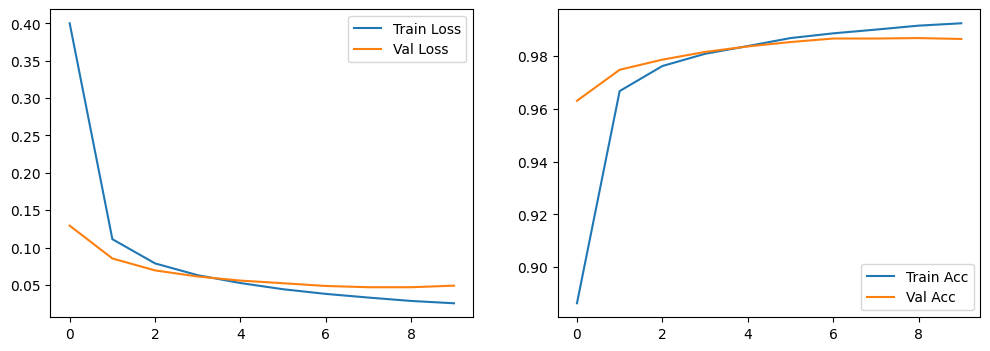

In [3]:
class MnistModelPipeline:
  def __init__(self):
    self.model = None
    self.history = None
    self.X_train = None
    self.X_test = None
    self.y_train = None
    self.y_test = None
    self.scaler = StandardScaler()

  def load_data(self):
    print("Loading MNIST dataset...")
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
    self.X_train = X_train
    self.y_train = y_train
    self.X_test = X_test
    self.y_test = y_test
    print(f"MNIST dataset loaded. X_train shape: {self.X_train.shape}, y_train shape: {self.y_train.shape}")

  def preprocess_data(self):
    print("Preprocessing MNIST dataset for CNN...")
    # Reshape to (28, 28, 1) for Convolutional Layers
    self.X_train = self.X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
    self.X_test = self.X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

    self.y_train = tf.keras.utils.to_categorical(self.y_train, num_classes=10)
    self.y_test = tf.keras.utils.to_categorical(self.y_test, num_classes=10)

    print(f"Preprocessing complete. X_train shape: {self.X_train.shape}")

  def build_model(self):
    num_classes = self.y_train.shape[1]

    # LeNet-5 Architecture
    self.model = keras.Sequential([
      keras.Input(shape=(28, 28, 1)),
      layers.Conv2D(filters=6, kernel_size=(5, 5), activation="relu", padding="same"), # C1
      layers.AveragePooling2D(pool_size=(2, 2)), # S2
      layers.Conv2D(filters=16, kernel_size=(5, 5), activation="relu", padding="valid"), # C3
      layers.AveragePooling2D(pool_size=(2, 2)), # S4
      layers.Conv2D(filters=120, kernel_size=(5, 5), activation="relu", padding="valid"), # C5
      layers.Flatten(),
      layers.Dense(units=84, activation="relu"), # F6
      layers.Dense(units=num_classes, activation="softmax") # Output layer
    ])

    self.model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    print("LeNet-5 Model built successfully")

  def train(self, epochs=10, batch_size=128):
    early_stopping = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    print(f"Starting training for {epochs} epochs")
    self.history = self.model.fit(
      self.X_train, self.y_train,
      validation_split=0.2,
      batch_size=batch_size,
      epochs=epochs,
      callbacks=[early_stopping],
      verbose=1
    )

  def evaluate_and_predict(self):
    y_pred_prob = self.model.predict(self.X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(self.y_test, axis=1)

    acc = accuracy_score(y_true, y_pred)
    print(f"\nTest Accuracy Score: {acc:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

  def visualize_performance(self):
    if self.history is None: return
    hist = self.history.history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(hist['loss'], label='Train Loss')
    plt.plot(hist['val_loss'], label='Val Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(hist['accuracy'], label='Train Acc')
    plt.plot(hist['val_accuracy'], label='Val Acc')
    plt.legend()
    plt.show()

if __name__ == "__main__":
  pipeline = MnistModelPipeline()
  pipeline.load_data()
  pipeline.preprocess_data()
  pipeline.build_model()
  pipeline.train(epochs=10)
  pipeline.evaluate_and_predict()
  pipeline.visualize_performance()


Original image shape: (28, 28)
True label: 7


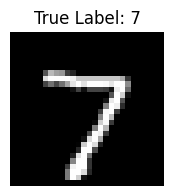

Processed image shape for model input: (1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step

Prediction Probabilities for each class: [[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]
Predicted Label: 7
Confidence: 1.0000
The model predicted correctly!


In [4]:
(_, _), (X_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

sample_index = 0
sample_image_original = X_test_raw[sample_index]
sample_true_label = y_test_raw[sample_index]

print(f"Original image shape: {sample_image_original.shape}")
print(f"True label: {sample_true_label}")

plt.figure(figsize=(2, 2))
plt.imshow(sample_image_original, cmap='gray')
plt.title(f"True Label: {sample_true_label}")
plt.axis('off')
plt.show()

# Fix: Reshape to (1, 28, 28, 1) for the CNN
sample_image_processed = sample_image_original.reshape(1, 28, 28, 1).astype('float32') / 255.0

print(f"Processed image shape for model input: {sample_image_processed.shape}")

prediction_probabilities = pipeline.model.predict(sample_image_processed)
predicted_label = np.argmax(prediction_probabilities)

print(f"\nPrediction Probabilities for each class: {np.round(prediction_probabilities, 3)}")
print(f"Predicted Label: {predicted_label}")
print(f"Confidence: {np.max(prediction_probabilities):.4f}")

if predicted_label == sample_true_label:
    print("The model predicted correctly!")
else:
    print("The model made an incorrect prediction.")

Image loaded successfully from /content/eight.jpeg


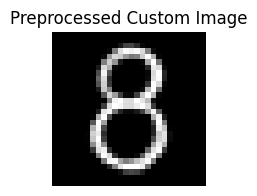

Processed image shape for model input: (1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Prediction Probabilities for each class: [[0.    0.    0.    0.001 0.    0.    0.    0.    0.999 0.   ]]
Predicted Label: 8
Confidence: 0.9992


In [6]:
from PIL import Image
image_path = '/content/eight.jpeg' # Ensure you upload this file to the folder icon on the left

try:
    custom_image = Image.open(image_path)
    print(f"Image loaded successfully from {image_path}")
    custom_image_gray = custom_image.convert(mode='L')
    custom_image_resized = custom_image_gray.resize((28, 28))
    img_array = np.array(custom_image_resized)

    # Invert colors if necessary (MNIST is white on black)
    if np.mean(img_array) > 128:
        img_array = 255 - img_array

    plt.figure(figsize=(2, 2))
    plt.imshow(img_array, cmap='gray')
    plt.title("Preprocessed Custom Image")
    plt.axis('off')
    plt.show()

    # Fix: Reshape to (1, 28, 28, 1) for the CNN
    custom_image_processed = img_array.reshape(1, 28, 28, 1).astype('float32') / 255.0
    print(f"Processed image shape for model input: {custom_image_processed.shape}")

    prediction_probabilities = pipeline.model.predict(custom_image_processed)
    predicted_label = np.argmax(prediction_probabilities)
    confidence = np.max(prediction_probabilities)

    print(f"\nPrediction Probabilities for each class: {np.round(prediction_probabilities, 3)}")
    print(f"Predicted Label: {predicted_label}")
    print(f"Confidence: {confidence:.4f}")

except FileNotFoundError:
    print(f"Error: Image file not found at {image_path}. Please upload 'eight.jpg' to the Colab files pane.")
except Exception as e:
    print(f"An error occurred: {e}")